# 🌲 Rozhodovací strom v klasifikaci – Teorie, kritéria a praktická implementace
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Zdrojový výukový materiál:** `Decision_tree_in_classification_-_introduction_and_implementation.pdf`  
> Tento sešit pokrývá kompletní teorii a realizaci klasifikačního stromu pro Den 2:
> 1. Principy rozhodovacího stromu v klasifikaci (přirozený multiclass, invariance vůči škálování).
> 2. Kritéria větvení uzlů: Shannonova Entropie & Informační zisk (Information Gain) vs. Giniho index nečistoty (Gini Impurity).
> 3. Školní implementace v Scikit-learn na syntetickém datasetu (`make_classification`, 600 vzorků, 5 příznaků).
> 4. Vizuální vykreslení architektury stromu (`plot_tree`) a analýza významnosti příznaků.
> 5. Srovnání chování kritérií Gini vs. Entropie.
> 6. Diagnostika přetrénování: Sweep hloubky `max_depth` a sledování rozdílu Train vs. Test.


## 1. Školní úloha: Syntetická data a Scikit-learn implementace
Přesná reprodukce kroků ze slajdů 17–18:
- Vygenerování datasetu pomocí `make_classification(n_samples=600, n_features=5, n_classes=2, random_state=42)`
- Rozdělení dat na trénovací a testovací sadu v poměru 70:30 (`train_test_split`)
- Inicializace a natrénování `DecisionTreeClassifier(criterion="gini", max_depth=5)`

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Vytvoření syntetického klasifikačního datasetu (slajd 17)
df = make_classification(n_samples=600, n_features=5, n_classes=2, random_state=42)

X = df[0]  # Nezávislé proměnné
y = df[1]  # Cílová proměnná (target)

# Rozdělení na trénovací a testovací sadu 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Inicializace a natrénování modelu s max_depth=5 (slajd 18)
clf_tree = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
clf_tree.fit(X_train, y_train)

print(f"Trénovací sada: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testovací sada : X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print(f"Hloubka natrénovaného stromu: {clf_tree.get_depth()}")
print(f"Počet koncových listů       : {clf_tree.get_n_leaves()}")


Trénovací sada: X_train = (420, 5), y_train = (420,)
Testovací sada : X_test  = (180, 5), y_test  = (180,)
Hloubka natrénovaného stromu: 5
Počet koncových listů       : 18


## 2. Predikce a výpočet evaluačních metrik (Slajdy 19–20)
Otestujeme model na testovací sadě a spočítáme celkovou přesnost (Accuracy) a přesnost pozitivních predikcí (Precision).

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Predikce na testovací sadě (slajd 19)
y_pred = clf_tree.predict(X_test)

# 2. Výpočet metrik (slajd 19)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=== VÝSLEDKY ŠKOLNÍHO MODELU (Slajdy 19-20) ===")
print(f"Accuracy score : {accuracy:.4f} ({accuracy*100:.2f} %)")
print(f"Precision score: {precision:.4f} ({precision*100:.2f} %)")
print(f"Recall score   : {recall:.4f} ({recall*100:.2f} %)")
print(f"F1-score       : {f1:.4f} ({f1*100:.2f} %)")
print(f"\nMatice záměn:\n{cm}")


=== VÝSLEDKY ŠKOLNÍHO MODELU (Slajdy 19-20) ===
Accuracy score : 0.9389 (93.89 %)
Precision score: 0.9263 (92.63 %)
Recall score   : 0.9565 (95.65 %)
F1-score       : 0.9412 (94.12 %)

Matice záměn:
[[81  7]
 [ 4 88]]


## 3. Matice záměn a významnost příznaků
Zobrazíme matici záměn a podíváme se, které příznaky strom vyhodnotil jako nejdůležitější pro separaci dat.

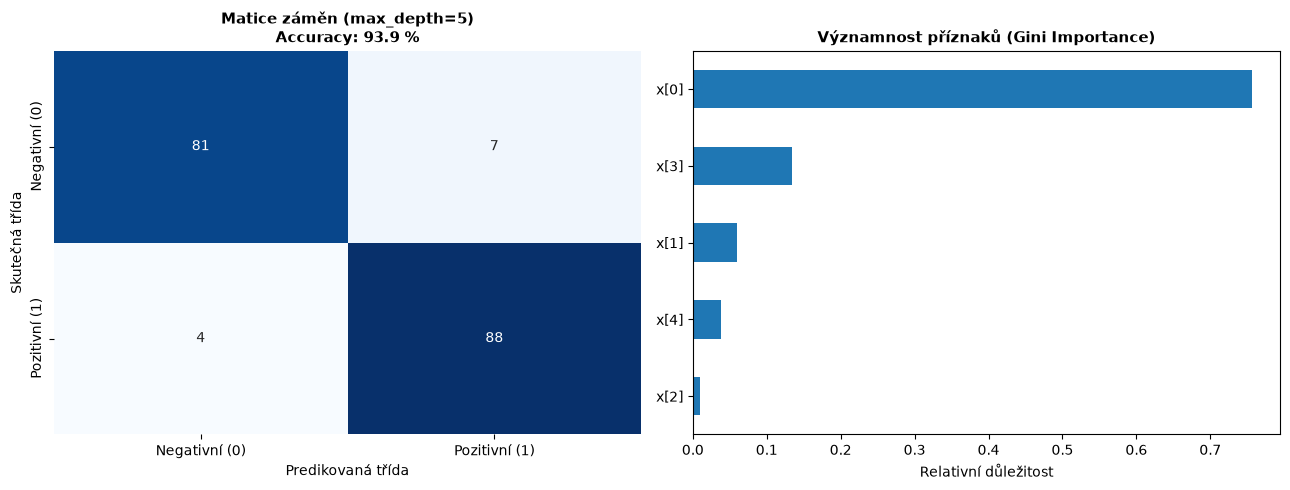

Relativní důležitost jednotlivých příznaků:
x[0]: 75.65 %
x[3]: 13.45 %
x[1]: 6.04 %
x[4]: 3.84 %
x[2]: 1.02 %


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Matice záměn
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Negativní (0)", "Pozitivní (1)"],
            yticklabels=["Negativní (0)", "Pozitivní (1)"])
axes[0].set_title(f"Matice záměn (max_depth=5)\nAccuracy: {accuracy*100:.1f} %", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predikovaná třída")
axes[0].set_ylabel("Skutečná třída")

# 2. Významnost příznaků (Feature Importances)
feat_names = [f"x[{i}]" for i in range(X.shape[1])]
feat_imp = pd.Series(clf_tree.feature_importances_, index=feat_names).sort_values(ascending=True)

feat_imp.plot(kind="barh", color="#1f77b4", ax=axes[1])
axes[1].set_title("Významnost příznaků (Gini Importance)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Relativní důležitost")

plt.tight_layout()
plt.show()

print("Relativní důležitost jednotlivých příznaků:")
for name, val in feat_imp.iloc[::-1].items():
    print(f"{name}: {val*100:.2f} %")


## 4. Vizuální vykreslení architektury stromu (`plot_tree`, Slajd 21)
Vykreslíme hierarchickou strukturu stromu se všemi rozhodovacími podmínkami, hodnotami Gini indexu, počty vzorků a převládajícími třídami.

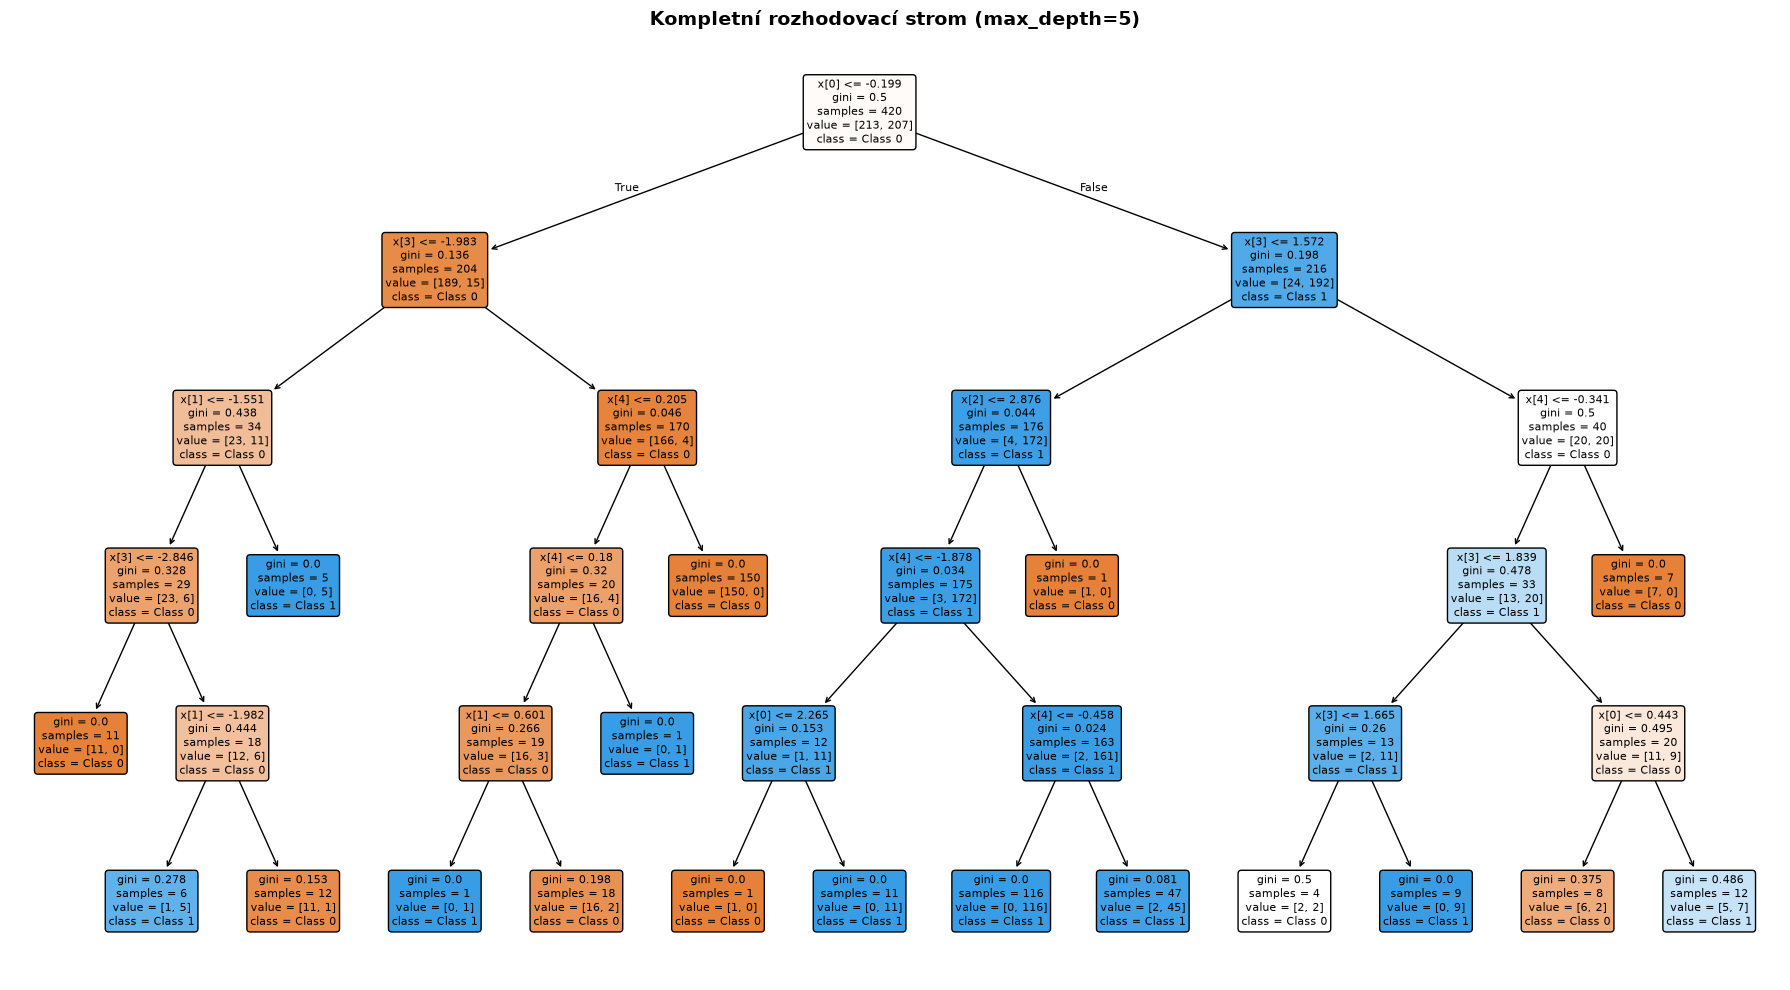

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    clf_tree,
    feature_names=feat_names,
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Kompletní rozhodovací strom (max_depth=5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Srovnání kritérií větvení: Gini index vs. Shannonova Entropie (Slajdy 8–14)
Vyzkoušíme, zda má volba kritéria (`criterion="gini"` vs. `criterion="entropy"`) vliv na konečnou přesnost a strukturu stromu.

In [5]:
# Trénování modelu s entropií (Informačním ziskem)
clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
clf_entropy.fit(X_train, y_train)

y_pred_ent = clf_entropy.predict(X_test)
acc_ent = accuracy_score(y_test, y_pred_ent)
prec_ent = precision_score(y_test, y_pred_ent)

comparison_df = pd.DataFrame({
    "Kritérium": ["Gini Impurity (gini)", "Shannonova Entropie (entropy)"],
    "Test Accuracy": [f"{accuracy*100:.2f} %", f"{acc_ent*100:.2f} %"],
    "Test Precision": [f"{precision*100:.2f} %", f"{prec_ent*100:.2f} %"],
    "Hloubka stromu": [clf_tree.get_depth(), clf_entropy.get_depth()],
    "Počet listů": [clf_tree.get_n_leaves(), clf_entropy.get_n_leaves()]
})

print("=== SROVNÁNÍ KRITÉRIÍ GINI vs. ENTROPIE ===")
print(comparison_df.to_string(index=False))


=== SROVNÁNÍ KRITÉRIÍ GINI vs. ENTROPIE ===
                    Kritérium Test Accuracy Test Precision  Hloubka stromu  Počet listů
         Gini Impurity (gini)       93.89 %        92.63 %               5           18
Shannonova Entropie (entropy)       91.11 %        93.18 %               5           17


## 6. Diagnostika přetrénování: Vliv hloubky `max_depth` (1 až 15)
Co se stane, když necháme strom růst do neomezené hloubky?
Trénovací přesnost dosáhne 100 %, ale testovací přesnost začne klesat (overfitting).

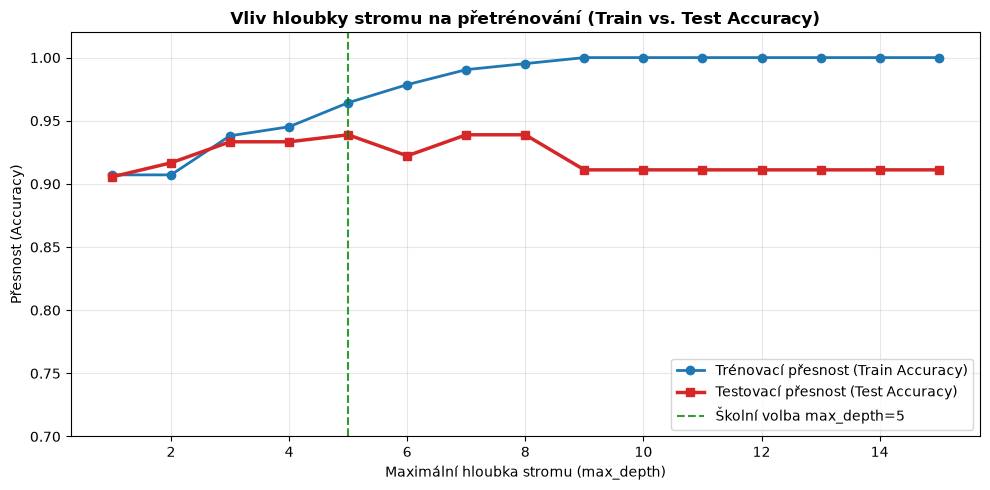

Při max_depth = 1 : Train = 90.7 %, Test = 90.6 % (Underfitting / Decision Stump)
Při max_depth = 5 : Train = 96.4 %, Test = 93.9 % (Optimální kompromis)
Při max_depth = 15: Train = 100.0 %, Test = 91.1 % (Rozdíl 8.9 % - Overfitting!)


In [6]:
depths = list(range(1, 16))
train_accs = []
test_accs = []

for d in depths:
    m = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker="o", color="#1f77b4", linewidth=2, label="Trénovací přesnost (Train Accuracy)")
plt.plot(depths, test_accs, marker="s", color="#d62728", linewidth=2.5, label="Testovací přesnost (Test Accuracy)")
plt.axvline(5, color="green", linestyle="--", alpha=0.8, label="Školní volba max_depth=5")

plt.title("Vliv hloubky stromu na přetrénování (Train vs. Test Accuracy)", fontsize=12, fontweight="bold")
plt.xlabel("Maximální hloubka stromu (max_depth)")
plt.ylabel("Přesnost (Accuracy)")
plt.ylim(0.70, 1.02)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Při max_depth = 1 : Train = {train_accs[0]*100:.1f} %, Test = {test_accs[0]*100:.1f} % (Underfitting / Decision Stump)")
print(f"Při max_depth = 5 : Train = {train_accs[4]*100:.1f} %, Test = {test_accs[4]*100:.1f} % (Optimální kompromis)")
print(f"Při max_depth = 15: Train = {train_accs[-1]*100:.1f} %, Test = {test_accs[-1]*100:.1f} % (Rozdíl {train_accs[-1]*100 - test_accs[-1]*100:.1f} % - Overfitting!)")


## 7. Závěrečné shrnutí a klíčové poznatky

1. **Principy klasifikačního stromu:**  
   Algoritmus vytváří pravoúhlé řezy příznakového prostoru s cílem maximalizovat čistotu vzniklých uzlů. Nativně řeší multiclass klasifikaci a je necitlivý na monotónní transformace měřítek.
2. **Kritéria větvení (Gini vs. Entropie):**  
   Gini Impurity měří pravděpodobnost chybného přiřazení a je výpočetně levnější (nevyžaduje logaritmy). Entropie měří informační chaos. Obě kritéria v praxi dosahují téměř totožné predikční síly.
3. **Výsledky školního modelu:**  
   Při `max_depth=5` dosáhl strom na syntetických datech **Accuracy $93.89\,\%$** a **Precision $92.63\,\%$**. Dominantním příznakem byl $x[0]$ s významností přes $75\,\%$.
4. **Prevence přetrénování:**  
   Bez omezení hloubky strom rychle dosáhne $100\,\%$ trénovací přesnosti, avšak testovací přesnost klesá. Parametr `max_depth=5` představuje ideální vyvážení biasu a variance.
